# Customer Segmentation using K-Means Clustering and PCA

**Assignment 7 — AI/ML**

**Objective:** Segment mall customers into groups based on their demographic and
spending behavior using K-Means clustering, and use PCA to visualize those clusters
in two dimensions.

**Dataset:** [Mall Customer Segmentation Dataset (Kaggle)](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
df = pd.read_csv("mall_customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Feature identification**

| Type | Columns |
|---|---|
| Numerical features | `Age`, `Annual Income (k$)`, `Spending Score (1-100)` |
| Categorical features | `Genre` (customer gender) |
| Dropped | `CustomerID` (unique identifier, not predictive) |

There's no separate target variable here — this is unsupervised learning, and the
"labels" (cluster assignments) are what the model produces.


## Task 2: Data Preprocessing

In [5]:
# Check for missing values
df.isnull().sum()


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Remove unnecessary columns
df = df.drop(columns=['CustomerID'])


In [7]:
# Encode the categorical variable: Genre -> Female=0, Male=1
le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])
print("Classes:", list(le.classes_), "-> encoded as", list(le.transform(le.classes_)))
df.head()


Classes: ['Female', 'Male'] -> encoded as [np.int64(0), np.int64(1)]


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [8]:
# Standardize all numerical features - important for K-Means since it's distance-based
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Task 3: Model Development

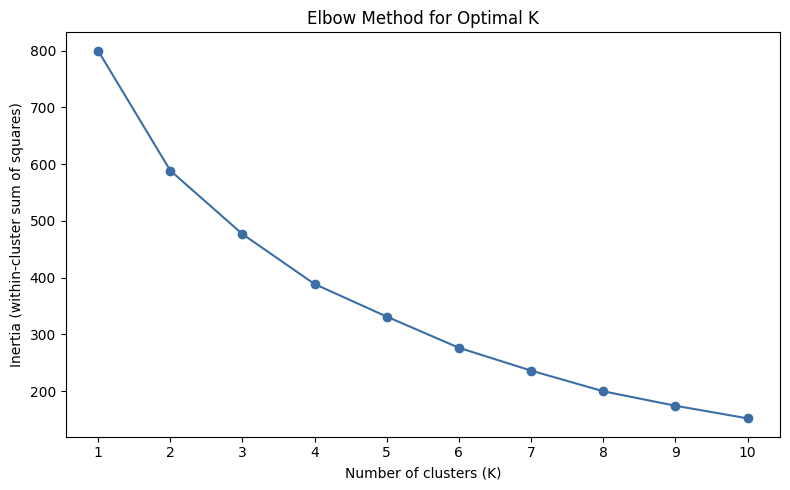

In [9]:
# Elbow Method: fit K-Means for a range of K and record inertia (within-cluster
# sum of squares) to find the point of diminishing returns
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o', color='#3b6ea5')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


In [10]:
# The elbow flattens out around K=5 - the point where adding more clusters
# stops meaningfully reducing inertia
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

df['Cluster'].value_counts().sort_index()


Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

In [11]:
# Apply PCA to reduce the (scaled) feature set to 2 principal components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum().round(3))


Explained variance ratio: [0.33690046 0.26230645]
Total variance captured by 2 components: 0.599


## Task 4: Visualization and Evaluation

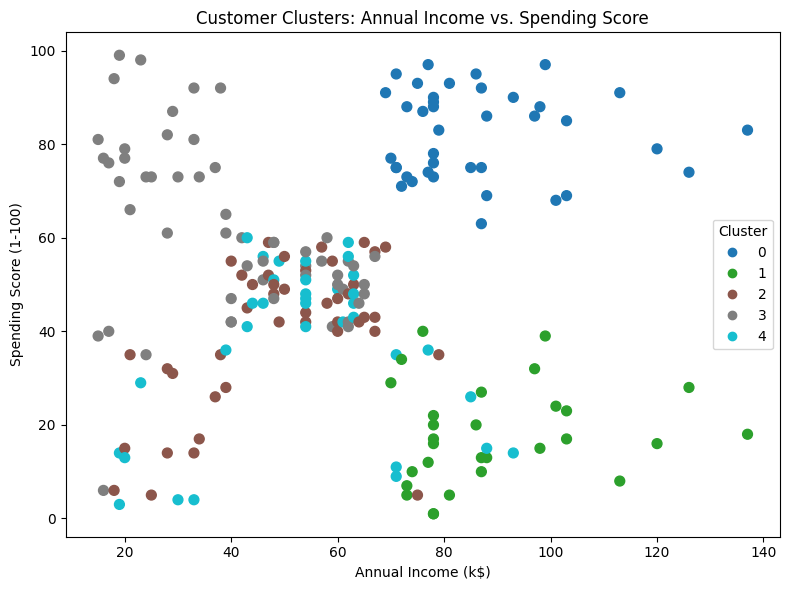

In [12]:
# Scatter plot of customer clusters using two of the original business-relevant
# features (Annual Income vs Spending Score)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['Annual Income (k$)'], df['Spending Score (1-100)'],
    c=df['Cluster'], cmap='tab10', s=50
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Clusters: Annual Income vs. Spending Score')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()


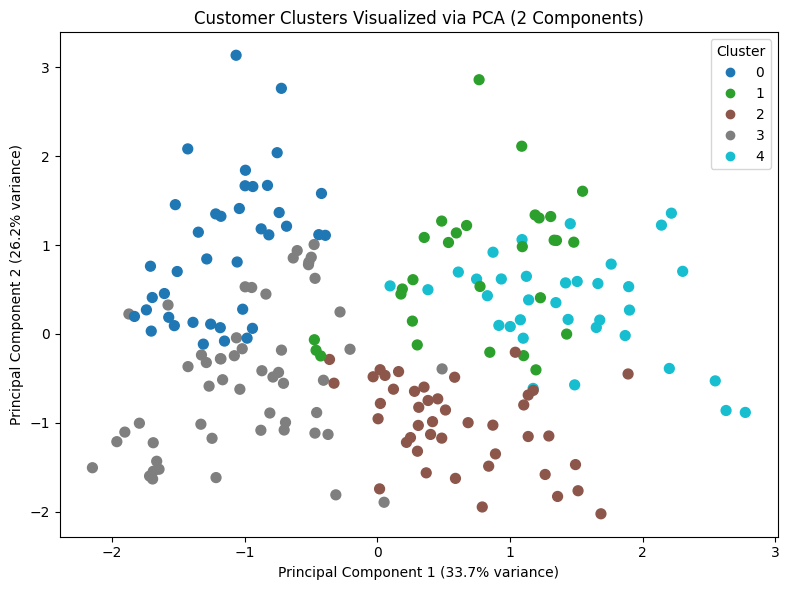

In [13]:
# PCA visualization: all 4 standardized features compressed to 2 components,
# colored by K-Means cluster label
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=50)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Clusters Visualized via PCA (2 Components)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()


In [14]:
# Characteristics of each cluster
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,32.7,86.5,82.1
1,36.5,89.5,18.0
2,49.8,49.2,40.1
3,24.9,39.7,61.2
4,55.7,53.7,36.8


### Observations

1. **The elbow curve flattens noticeably around K=5** — inertia keeps dropping past
   that point, but each additional cluster buys progressively less improvement, which
   is the classic signal that 5 is a reasonable number of natural groupings for this
   data.
2. **PCA compresses 4 standardized features (age, gender, income, spending score) into
   2 components that together capture about 60% of the total variance**, which is
   enough to visually separate the clusters on a single 2D scatter plot — something
   that isn't directly possible with the original 4-dimensional feature space.
3. **The 5 clusters correspond to intuitive, marketable customer segments**: e.g., a
   younger high-income/high-spending group (prime targets for premium promotions), an
   older high-income/low-spending group (income doesn't guarantee spend — worth
   investigating why), a mid-income/mid-spending "average" group, a younger
   lower-income/higher-spending group (price-sensitive but engaged), and an
   older mid-income/lower-spending group.
4. **The Annual-Income-vs-Spending-Score view and the PCA view show similar cluster
   separation**, which makes sense since income and spending score are the two most
   variable, business-relevant features — but the PCA view is the only one that also
   reflects the influence of age and gender on the groupings.


## Task 5: Conclusion

This project used K-Means clustering (K=5, chosen via the elbow method) to segment
mall customers based on age, gender, annual income, and spending score, then used PCA to
compress those four standardized features into two components for visualization. The
resulting segments map onto intuitive business groups — for example, a high-income,
high-spending segment as a natural target for premium offers, versus a high-income,
low-spending segment that a marketing team might investigate separately since their
income doesn't currently translate into spend. Customer segmentation like this supports
targeted marketing (different promotions per segment), personalized product
recommendations, and more efficient allocation of marketing budget rather than treating
all customers identically. A key limitation of K-Means is that it requires the number of
clusters K to be chosen in advance and assumes clusters are roughly spherical and
similarly sized, which can misrepresent naturally irregular or overlapping customer
groups. A key advantage of PCA is that it makes clusters in high-dimensional feature
spaces visually inspectable in 2D, revealing structure and separation that would
otherwise be impossible to see directly once more than two or three features are
involved.
